In [19]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from PIL import Image
import glob
import shutil
import shap

# **data cleaning** 

In [20]:


csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
dst="/kaggle/working/clean_data/"
csvdst = "/kaggle/working/clean_data/csv"
imgdst="/kaggle/working/clean_data/img"
os.makedirs(dst, exist_ok=True)
os.makedirs(csvdst, exist_ok=True)
os.makedirs(imgdst, exist_ok=True)
count=0
totalcount=0
for paths in csv_path:
    
    if paths.endswith('.csv'):
        totalcount+=1
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".csv",".jpg"))
        if os.path.isfile(imgpth):
            shutil.copy(act_path, csvdst)
            shutil.copy(imgpth, imgdst)
        else:
            print(paths,'skipped')
print('done')
              
        


1674-F-050Y1(1).csv skipped
1669-M-048Y1(1).csv skipped
1667-F-065Y1(1).csv skipped
done


# data exploration

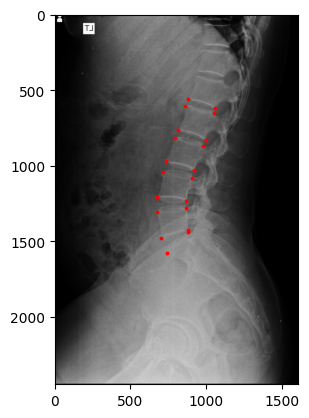

In [21]:
#data exploration on images after cleaning
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/working/clean_data/csv"
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break


/tmp/ipykernel_58/1065733884.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)


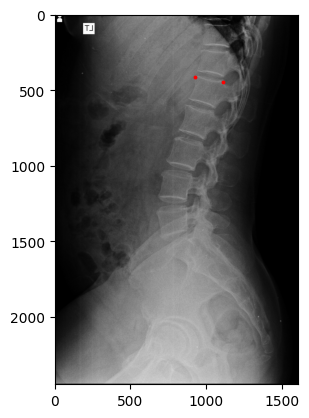

In [22]:
#data on excel
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"

count =0
info=pd.read_excel(csvdir,sheet_name='Pos_LA',index_col='filename')
for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        fig,ax=plt.subplots()
        ax.imshow(img)
        if name in info.index:
            row_data = info.loc[name]
        #use this:
        ax.scatter(row_data.iloc[3],row_data.iloc[4],c='red',s=3)
        #avoid this:
        ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)
        
        #ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break

Index(['lumbar', 'diagnosis_number', '   ', 'gender', 'Unnamed: 5',
       'Count of diagnosis_title', 'Column Labels', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')
Anterolisthesis


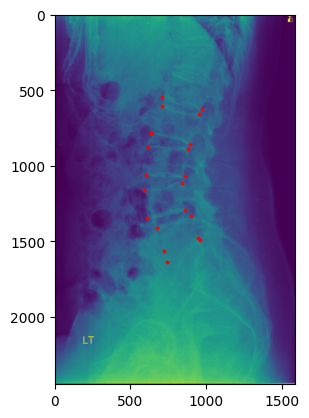

Retrolisthesis


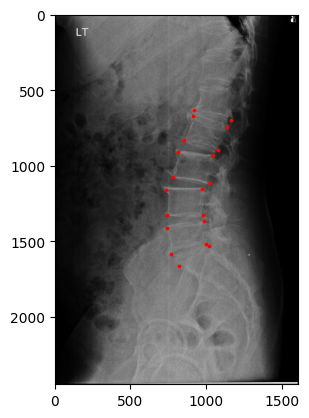

note: no left or right Laterolisthesis as dataset is dealing with only sagittal view


In [23]:
# data on excel according to diagnosis
imagedir='/kaggle/working/clean_data/img'
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
csvdir="/kaggle/working/clean_data/csv"
count1,count2,count3,count4=0,0,0,0
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis',index_col='filename')
print(diaginfo.columns)

for fname in os.listdir(imagedir):
    if fname.endswith('.jpg'):
        name=os.path.splitext(fname)[0]
        if name in diaginfo.index:
            current_diagnosis = diaginfo.loc[name, 'diagnosis_number']
            
            
            if isinstance(current_diagnosis, pd.Series):
                has_3 = 3 in current_diagnosis.values
                has_4 = 4 in current_diagnosis.values
            else:
                has_3 = (current_diagnosis == 3)
                has_4 = (current_diagnosis == 4)
            
                
            if has_3 and count3 == 0:
                print("Anterolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count3 += 1
                
            elif has_4 and count4 == 0:
                print("Retrolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count4 += 1
            
            if count3 > 0 and count4 > 0:
                break

print("note: no left or right Laterolisthesis as dataset is dealing with only sagittal view")

In [24]:
import statistics
imagedir='/kaggle/working/clean_data/img'
h,w=[],[]
for fname in os.listdir(imagedir):
    with Image.open(os.path.join(imagedir,fname)) as img:
        width, height = img.size
        h.append(height)
        w.append(width)
print("height means and std:",statistics.mean(h),statistics.stdev(h))
print("width means and std:",statistics.mean(w),statistics.stdev(w))        

height means and std: 2490.55897862892 220.75834935727764
width means and std: 1812.5736885928393 383.02430512850987


In [25]:
#data preperation

from pandas import DataFrame
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis')
csvinfo=pd.read_excel(xldir,sheet_name='Pos_LA')
xldst = "/kaggle/working/clean_data/excel"
os.makedirs(xldst, exist_ok=True)

diaginfo['diagnosis_no'] = diaginfo['diagnosis_number'].apply(lambda x: x if x in [3, 4] else 0)
diag_subset = diaginfo[['filename', 'diagnosis_no']]
df = pd.merge(csvinfo, diag_subset, on='filename', how='left')
df['diagnosis_no'] = df['diagnosis_no'].fillna(0).astype(int)
print(df.columns)
df['gender'] = df['gender'].apply(lambda x: 0 if x == 'M' else 1)


output_path = os.path.join(xldst, 'test.xlsx') 
df.to_excel(output_path, sheet_name='sheet1', index=False)

print('merged diagnosis and points positions successfully')
        

Index(['filename', 'gender', 'age', 'type', 'L1a_1c', 'L1a_1r', 'L1a_2c',
       'L1a_2r', 'L1b_1c', 'L1b_1r', 'L1b_2c', 'L1b_2r', 'L2a_1c', 'L2a_1r',
       'L2a_2c', 'L2a_2r', 'L2b_1c', 'L2b_1r', 'L2b_2c', 'L2b_2r', 'L3a_1c',
       'L3a_1r', 'L3a_2c', 'L3a_2r', 'L3b_1c', 'L3b_1r', 'L3b_2c', 'L3b_2r',
       'L4a_1c', 'L4a_1r', 'L4a_2c', 'L4a_2r', 'L4b_1c', 'L4b_1r', 'L4b_2c',
       'L4b_2r', 'L5a_1c', 'L5a_1r', 'L5a_2c', 'L5a_2r', 'L5b_1c', 'L5b_1r',
       'L5b_2c', 'L5b_2r', 'S1a_1c', 'S1a_1r', 'S1a_2c', 'S1a_2r', 'L1b_d',
       'L2b_d', 'L3b_d', 'L4b_d', 'L5b_d', 'diagnosis_no'],
      dtype='object')
merged diagnosis and points positions successfully


In [26]:
# #data exploration
# missing_val_count_by_column = (X.isnull().sum())
# print(missing_val_count_by_column[missing_val_count_by_column > 0])
# print("no missing values in dataset")

In [27]:
#for raw data

# #check best hyperparameters
# #on raw coordinates
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


xldst = "/kaggle/working/clean_data/excel/test.xlsx"
spine_data = pd.read_excel(xldst,sheet_name='sheet1', index_col='filename')
y = spine_data.diagnosis_no


# Geometric Feature Extraction

1. Vertebral Tilt
2. Intersegmental Angles
3. Anterior and Posterior Disc Heights and compression ratio
4. Aspect Ratio
5. Slippage Distance between L4 and L5
6. Signed Sagittal Translation (positive for Anterolisthesis)
7.  Percentage Spondylolisthesis
8.  cobbs angle(L1-S1)


In [28]:


import numpy as np

def euclidean_distance(p1x, p1y, p2x, p2y):
        return np.sqrt((p1x-p2x)**2+(p1y-p2y)**2)

def angle_calc(p1x, p1y, p2x, p2y):
    return np.degrees(np.arctan2((p1y-p2y),(p1x-p2x)))

def angle_calc_lines(p1x, p1y, p2x, p2y,p3x, p3y, p4x, p4y):
    m1=(p1y-p2y)/(p1x-p2x)
    m2=(p3y-p4y)/(p3x-p4x)
    return np.degrees(np.arctan2((m1-m2),(1+m1*m2)))
    
def cobbs_angle(max1,min1):
    return (np.degrees(np.pi)-max1+min1)

In [29]:
def extract_geometric_features(df):
    features=pd.DataFrame(index=df.index)
    features['gender']=df['gender']
    features['age'] = df['age']
    if 'type' in df.columns:
        features['type'] = df['type']
    #Vertebral Tilt
    levels = ['L1a', 'L1b', 'L2a', 'L2b', 'L3a', 'L3b', 'L4a', 'L4b', 'L5a', 'L5b', 'S1a']
    for lvl in levels:
        features[f'v_tilt_{lvl}'] = angle_calc(
            df[f'{lvl}_1c'], df[f'{lvl}_1r'], 
            df[f'{lvl}_2c'], df[f'{lvl}_2r']
            )
    #Intersegmental Angles
    features['int_seg_l1_l2']=angle_calc_lines(df['L1b_1c'], df['L1b_1r'], df['L1b_2c'], df['L1b_2r'],df['L2a_1c'], df['L2a_1r'], df['L2a_2c'], df['L2a_2r'])
    features['int_seg_l2_l3']=angle_calc_lines(df['L2b_1c'], df['L2b_1r'], df['L2b_2c'], df['L2b_2r'],df['L3a_1c'], df['L3a_1r'], df['L3a_2c'], df['L3a_2r'])
    features['int_seg_l3_l4']=angle_calc_lines(df['L3b_1c'], df['L3b_1r'], df['L3b_2c'], df['L3b_2r'],df['L4a_1c'], df['L4a_1r'], df['L4a_2c'], df['L4a_2r'])
    features['int_seg_l4_l5']=angle_calc_lines(df['L4b_1c'], df['L4b_1r'], df['L4b_2c'], df['L4b_2r'],df['L5a_1c'], df['L5a_1r'], df['L5a_2c'], df['L5a_2r'])
    features['int_seg_l5_s1']=angle_calc_lines(df['L5b_1c'], df['L5b_1r'], df['L5b_2c'], df['L5b_2r'],df['S1a_1c'], df['S1a_1r'], df['S1a_2c'], df['S1a_2r'])
    
    #cobb's angle
    
    tilt_cols = [f'v_tilt_{lvl}' for lvl in levels]
    features['cobbs_angle'] = features[tilt_cols].max(axis=1) - features[tilt_cols].min(axis=1)
            
    #Anterior and Posterior Disc Height
    
    for i in range(1,len(levels),2):
        lvl =levels[i]
        if lvl.endswith('b'):
            features[f'a_disl_h_{lvl}_{levels[i+1]}'] = euclidean_distance(
                    df[f'{lvl}_1c'], df[f'{lvl}_1r'], 
                    df[f'{levels[i+1]}_1c'], df[f'{levels[i+1]}_1r']
                )
            
            features[f'p_disl_h_{lvl}_{levels[i+1]}'] = euclidean_distance( 
                    df[f'{lvl}_2c'], df[f'{lvl}_2r'], 
                    df[f'{levels[i+1]}_2c'], df[f'{levels[i+1]}_2r']
                )  
    
            features[f'compr_ratio_{lvl}_{levels[i+1]}']= features[f'a_disl_h_{lvl}_{levels[i+1]}'] /( features[f'p_disl_h_{lvl}_{levels[i+1]}'] + 1e-9)
    
    #Aspect Ratio , Slippage Distance between L4 and L5
    
    #Aspect Ratio
    
    for i in range(0, len(levels)-1, 2):
        lvl_a = levels[i]       # Superior endplate
        lvl_b = levels[i+1]     # Inferior endplate 
        
        if lvl_a.endswith('a') and lvl_b.endswith('b'):
            
            ant_vert_h = euclidean_distance(
                df[f'{lvl_a}_1c'], df[f'{lvl_a}_1r'], 
                df[f'{lvl_b}_1c'], df[f'{lvl_b}_1r']
            )
            
            post_vert_h = euclidean_distance(
                df[f'{lvl_a}_2c'], df[f'{lvl_a}_2r'], 
                df[f'{lvl_b}_2c'], df[f'{lvl_b}_2r']
            )
            
            endplate_width = euclidean_distance(
                df[f'{lvl_a}_1c'], df[f'{lvl_a}_1r'], 
                df[f'{lvl_a}_2c'], df[f'{lvl_a}_2r']
            )
            
            avg_vert_h = (ant_vert_h + post_vert_h) / 2.0
            vert_name = lvl_a[:2] 
            
            features[f'aspect_ratio_{vert_name}'] = endplate_width / (avg_vert_h + 1e-9)

    # Slippage Distance between L3, L4, L5 and S1 with sign
    
    features[f'slip_dist_L3_L4'] = df['L3b_2c'] - df['L4a_2c']
    features[f'slip_dist_L4_L5'] = df['L4b_2c'] - df['L5a_2c']
    features[f'slip_dist_L5_S1'] = df['L5b_2c'] - df['S1a_2c']
    
    #Tangential vector projection
    
    v_L5_x = df['L5a_2c'] - df['S1a_2c']
    v_L5_y = df['L5a_2r'] - df['S1a_2r']
    v_slip_x = df['L4b_2c'] - df['L5a_2c']
    v_slip_y = df['L4b_2r'] - df['L5a_2r']
    
    # Cross product
    features['L4_L5_step_off'] =  (v_slip_x * v_L5_y - v_slip_y * v_L5_x) / (np.sqrt(v_L5_x**2 + v_L5_y**2)+ 1e-9)
    
    #Taillard’s Method for Percentage Spondylolisthesis
    lvl='L4b'
    features[f'perct_spond']= 100*features[f'slip_dist_L4_L5']  / (euclidean_distance( df[f'{lvl}_1c'], df[f'{lvl}_1r'], df[f'{lvl}_2c'], df[f'{lvl}_2r']) + 1e-9)


    return features


# model training

In [30]:
# xgboost with cross validation
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


def predict_acc_to_leaves(n_estimators, no_of_leaves,X, y):
    xgb_model = XGBClassifier(n_estimators=n_estimators,learning_rate=0.05, max_leaves=no_of_leaves,random_state=1)
    
    score=cross_val_score(xgb_model, X,y,cv=5,scoring='accuracy' 
    )
    return score.mean()



In [31]:
X_geometric = extract_geometric_features(spine_data)
X = pd.get_dummies(X_geometric, columns=['type'], drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [32]:
xgb_model = XGBClassifier(n_estimators=1000,learning_rate=0.05, max_leaves=500,random_state=1,eval_metric='mlogloss')
xgb_model.fit(X, y_encoded)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)
print('best model trained')

best model trained


# results

accuracy: [0.90257104 0.88768606 0.90933694 0.90933694 0.91610284]
avg accuracy: 0.9050067658998648
0: Normal, 1: Anterolisthesis, 2: Reterolisthesis


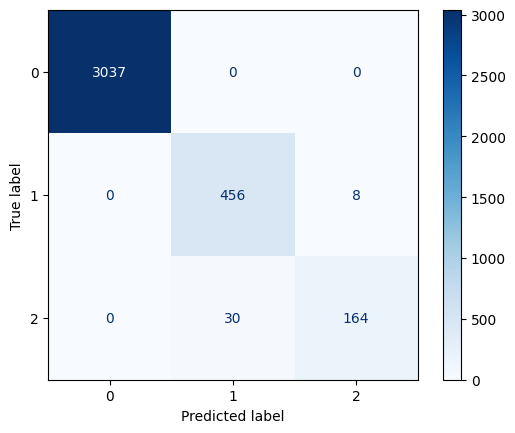

In [42]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred=xgb_model.predict(X)
cm=confusion_matrix(y_encoded,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap=plt.cm.Blues)
score=cross_val_score(xgb_model, X,y_encoded,cv=5,scoring='accuracy' 
    )
print('accuracy:',score)
print("avg accuracy:", score.mean())
print('0: Normal, 1: Anterolisthesis, 2: Reterolisthesis')
plt.show()

FEATURE IMPORTANCE TABLE
                Feature  Importance
0        L4_L5_step_off    0.159279
1       slip_dist_L3_L4    0.099121
2       slip_dist_L5_S1    0.075798
3       slip_dist_L4_L5    0.067220
4                   age    0.041891
5           perct_spond    0.041648
6      p_disl_h_L3b_L4a    0.030914
7      p_disl_h_L5b_S1a    0.022895
8      a_disl_h_L3b_L4a    0.019458
9       aspect_ratio_L2    0.019410
10     p_disl_h_L4b_L5a    0.019124
11      aspect_ratio_L5    0.019100
12  compr_ratio_L5b_S1a    0.016334
13     a_disl_h_L2b_L3a    0.016187
14      aspect_ratio_L3    0.015264
15           v_tilt_L5b    0.015204
16           v_tilt_L5a    0.015059
17     a_disl_h_L1b_L2a    0.014339
18           v_tilt_S1a    0.013924
19     p_disl_h_L2b_L3a    0.013861
20        int_seg_l4_l5    0.013717
21     a_disl_h_L4b_L5a    0.013558
22      aspect_ratio_L4    0.013016
23     a_disl_h_L5b_S1a    0.012991
24           v_tilt_L2a    0.012391
25      aspect_ratio_L1    0.012245
26 

/tmp/ipykernel_58/1944784605.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


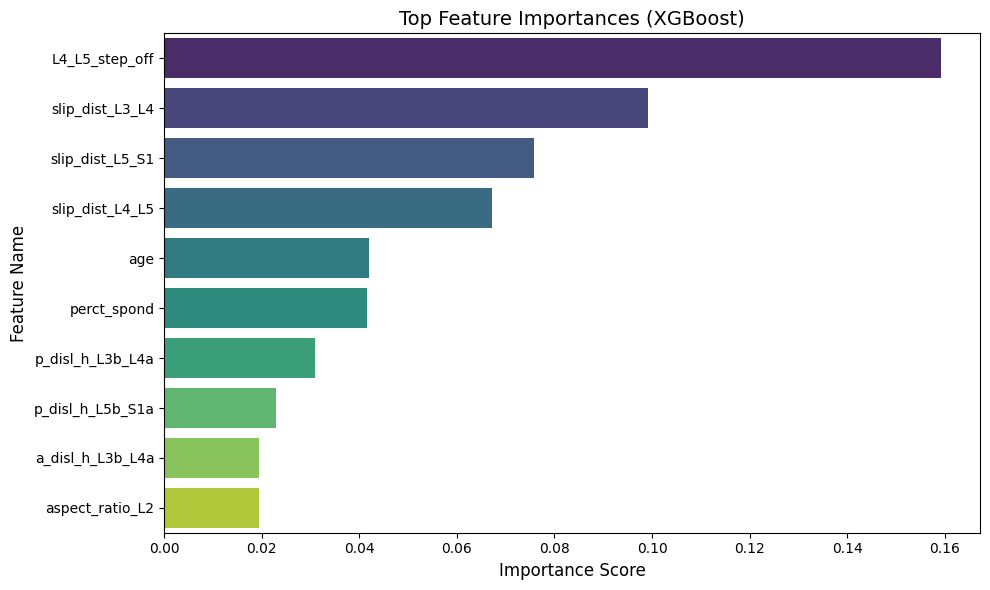

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_table = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_table = feature_table.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("FEATURE IMPORTANCE TABLE")
print(feature_table)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_table.head(10), 
    palette='viridis'
)

plt.title('Top Feature Importances (XGBoost)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

# shap plots
- Each dot is one patient.
- Y-axis = which feature (ranked by importance, most important at top)
- X-axis = how much that feature pushed the prediction — right means pushed toward that class, left means pushed away
- Color = the actual value of that feature for that patient — red = high value, blue = low value

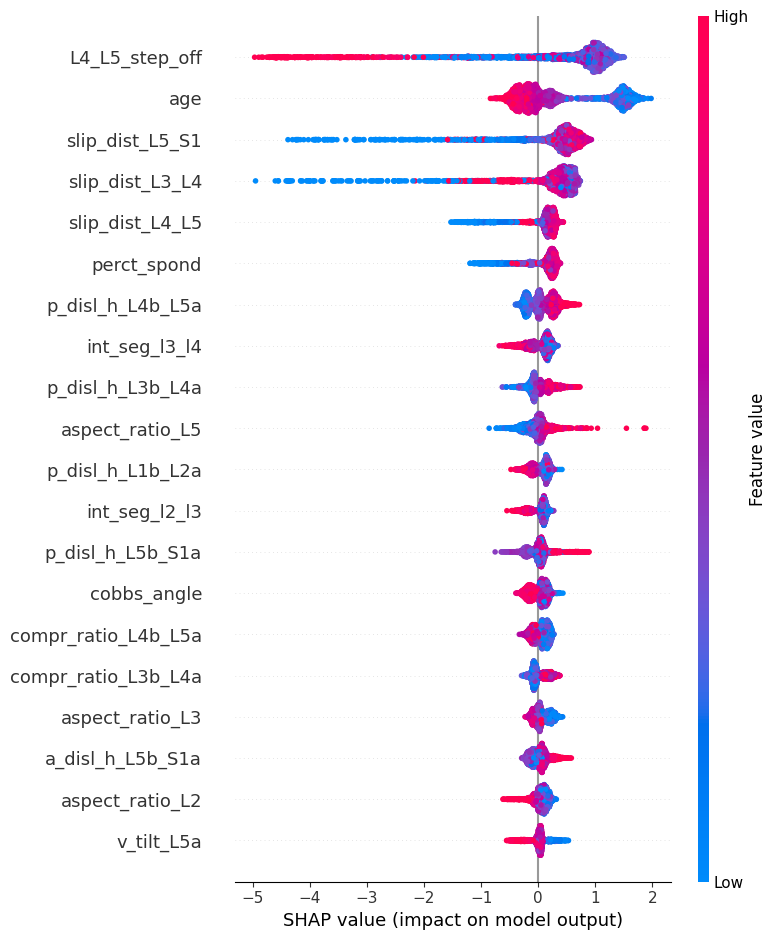

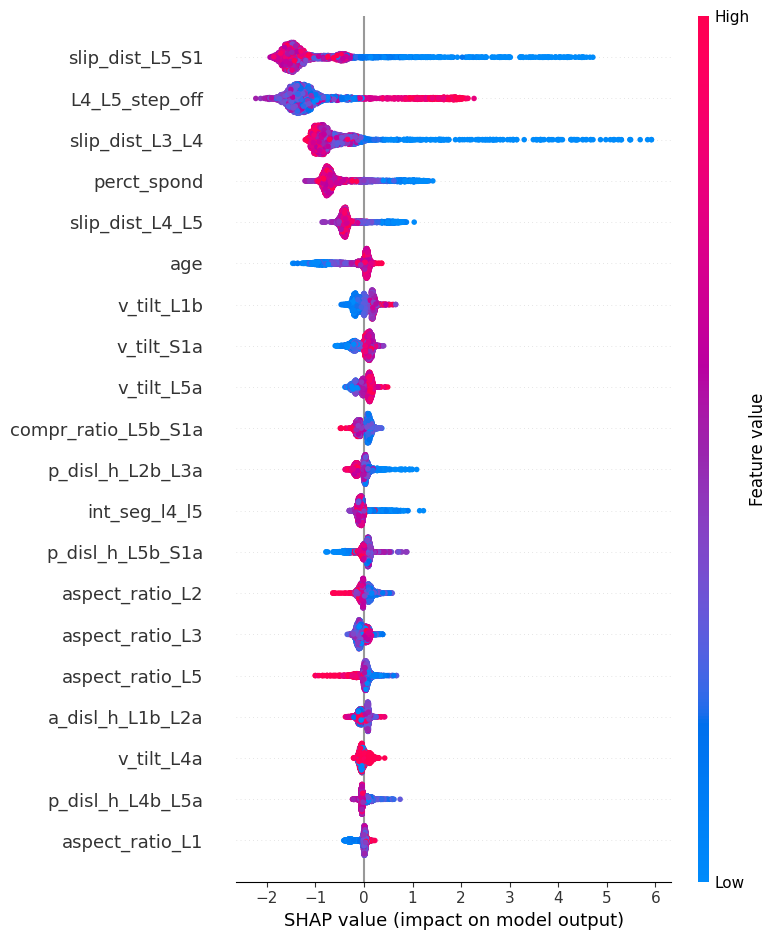

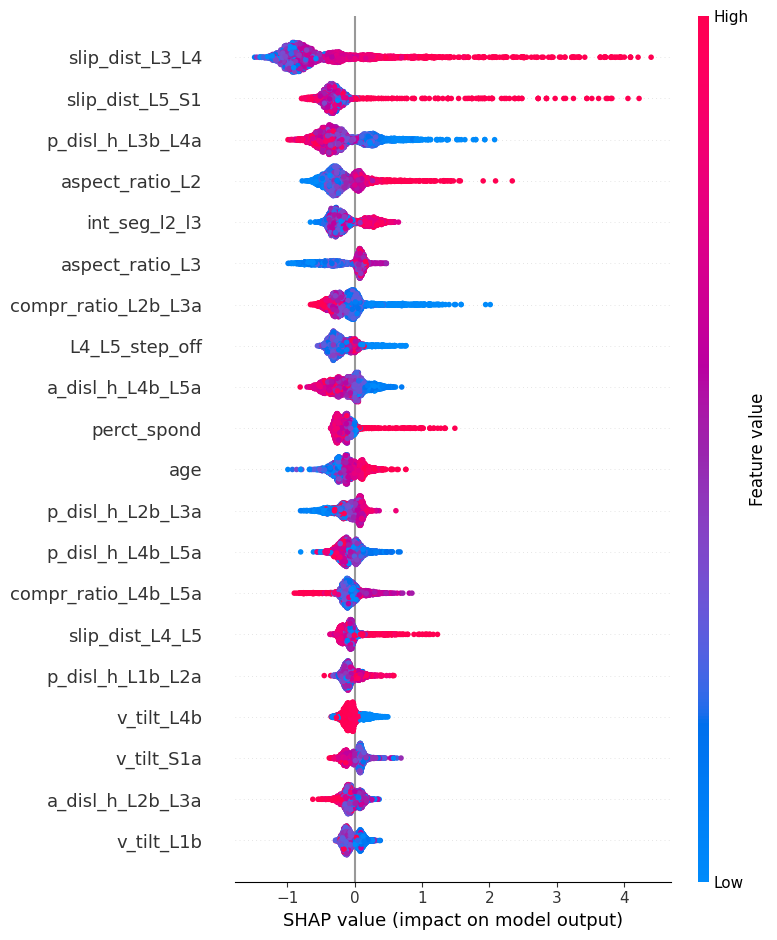

In [39]:

explainer = shap.TreeExplainer(xgb_model)
shap_explanation = explainer(X)  
shap.summary_plot(shap_explanation[:, :, 0], X) #on normal
shap.summary_plot(shap_explanation[:, :, 1], X) #on anterolithesis
shap.summary_plot(shap_explanation[:, :, 2], X) #on retrolethesis